In [89]:
!pip install faker
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot  as plt
import faker as Faker
#Faker is a Python library used to generate fake but realistic data.

In [90]:
fake = Faker.Faker()
np.random.seed(42)
N = 2000
#Number of customers = 2000 rows

In [91]:
# Customer IDs
customer_ids = [f"CUST{1000+i}" for i in range(N)]

In [92]:
# Names
names = [fake.name() for _ in range(N)]

In [93]:
# Age
ages = np.random.randint(18, 71, size=N)

In [94]:
# Gender
genders = np.random.choice(["Male", "Female"], size=N)

In [95]:
# Annual Income
annual_income = np.random.normal(loc=60000, scale=15000, size=N)
annual_income = np.clip(annual_income, 20000, 150000).astype(int)

In [96]:
# Membership Level (income-based)
membership_levels = []
for income in annual_income:
    if income < 40000:
        membership_levels.append("Basic")
    elif income < 70000:
        membership_levels.append("Silver")
    elif income < 100000:
        membership_levels.append("Gold")
    else:
        membership_levels.append("Platinum")

In [97]:
# Purchase Frequency (per month)
purchase_frequency = []
for level in membership_levels:
    if level == "Basic":
        purchase_frequency.append(np.random.randint(1, 4))
    elif level == "Silver":
        purchase_frequency.append(np.random.randint(3, 7))
    elif level == "Gold":
        purchase_frequency.append(np.random.randint(5, 10))
    else:
        purchase_frequency.append(np.random.randint(8, 15))

purchase_frequency = np.array(purchase_frequency)

In [98]:
# Spending Score
spending_score = (
    0.5 * (annual_income / annual_income.max()) +
    0.5 * (purchase_frequency / purchase_frequency.max())
) * 100

spending_score += np.random.normal(0, 5, N)
spending_score = np.clip(spending_score, 1, 100).astype(int)

In [99]:
# Average Transaction Value (USD)
avg_transaction_value = (
    0.6 * (annual_income / annual_income.max()) +
    0.4 * (spending_score / 100)
) * 300

avg_transaction_value += np.random.normal(0, 20, N)
avg_transaction_value = np.clip(avg_transaction_value, 20, 500).astype(int)

In [100]:
# Create DataFrame
df = pd.DataFrame({
    "CustomerID": customer_ids,
    "Name": names,
    "Age": ages,
    "Gender": genders,
    "Annual_Income": annual_income,
    "Spending_Score": spending_score,
    "Purchase_Frequency": purchase_frequency,
    "Average_Transaction_Value": avg_transaction_value,
    "Membership_Level": membership_levels
})



In [101]:
# Save dataset
df.to_csv("customer_segmentation_data.csv", index=False)

df.head()

,CustomerID,Name,Age,Gender,Annual_Income,Spending_Score,Purchase_Frequency,Average_Transaction_Value,Membership_Level
0,CUST1000,Christopher Frey,56,Male,65509,36,3,169,Silver
1,CUST1001,Chad Ford,69,Female,87572,58,7,218,Gold
2,CUST1002,Dana Fitzgerald,46,Female,56648,38,3,115,Silver
3,CUST1003,Haley Johnson,32,Female,54760,51,6,156,Silver
4,CUST1004,Angela Mccarthy,60,Female,59708,42,4,132,Silver


In [102]:
df.shape


(2000, 9)

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   CustomerID                 2000 non-null   object
 1   Name                       2000 non-null   object
 2   Age                        2000 non-null   int64 
 3   Gender                     2000 non-null   object
 4   Annual_Income              2000 non-null   int64 
 5   Spending_Score             2000 non-null   int64 
 6   Purchase_Frequency         2000 non-null   int64 
 7   Average_Transaction_Value  2000 non-null   int64 
 8   Membership_Level           2000 non-null   object
dtypes: int64(5), object(4)
memory usage: 140.8+ KB


In [104]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

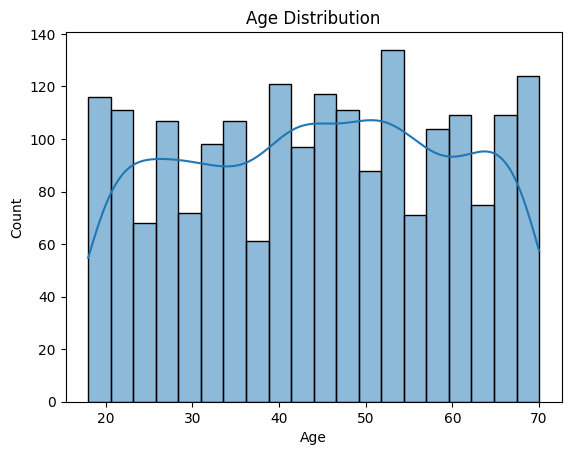

In [105]:
plt.figure()
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()
#Bins are simply the containers used to group values in a histogram
# if spending score KDE has multiple peaks, clustering is likely to work well.

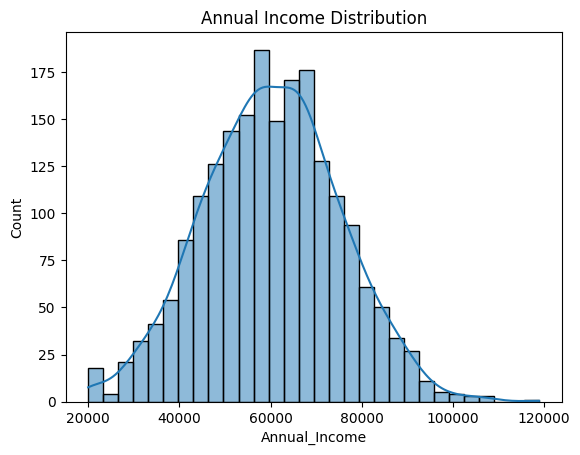

In [106]:
plt.figure()
sns.histplot(df["Annual_Income"], bins=30, kde=True)
plt.title("Annual Income Distribution")
plt.show()


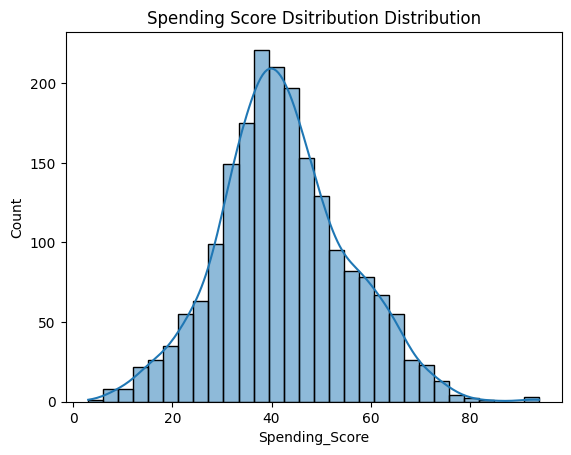

In [107]:
plt.figure()
sns.histplot(df["Spending_Score"], bins=30, kde=True)
plt.title("Spending Score Dsitribution Distribution")
plt.show()


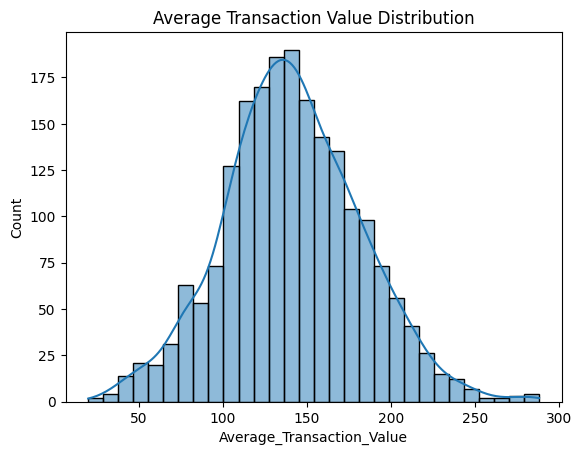

In [108]:
plt.figure()
sns.histplot(df["Average_Transaction_Value"], bins=30, kde=True)
plt.title("Average Transaction Value Distribution")
plt.show()


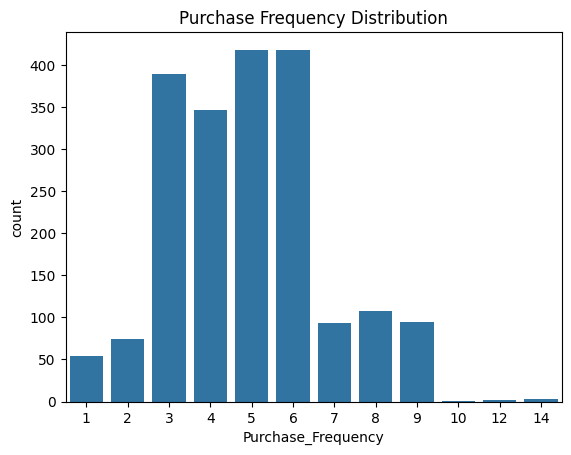

In [109]:
plt.figure()
sns.countplot(x="Purchase_Frequency", data=df)
plt.title("Purchase Frequency Distribution")
plt.show()


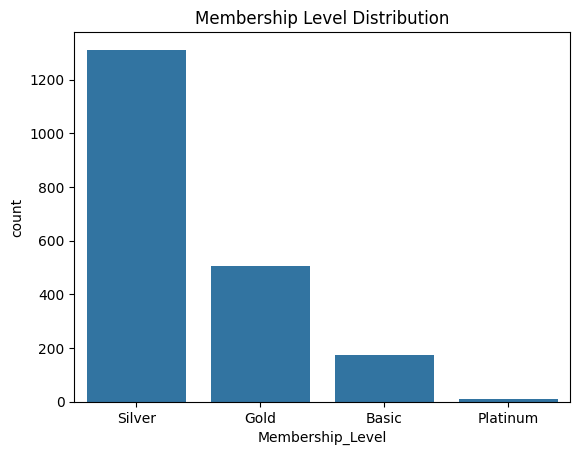

In [110]:
plt.figure()
sns.countplot(x="Membership_Level", data=df)
plt.title("Membership Level Distribution")
plt.show()


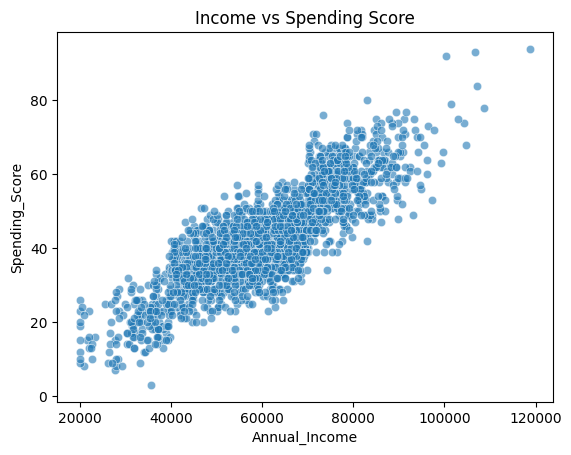

In [111]:
#Bivarate analysis
plt.figure()
sns.scatterplot(
    x="Annual_Income",
    y="Spending_Score",
    data=df,
    alpha=0.6
)
plt.title("Income vs Spending Score")
plt.show()


| Variable Type              | Plot Used    |
| -------------------------- | ------------ |
| numeric vs numeric         | Scatter plot |
| numeric vs categorical     | Box plot     |
| categorical vs categorical | Count plot   |


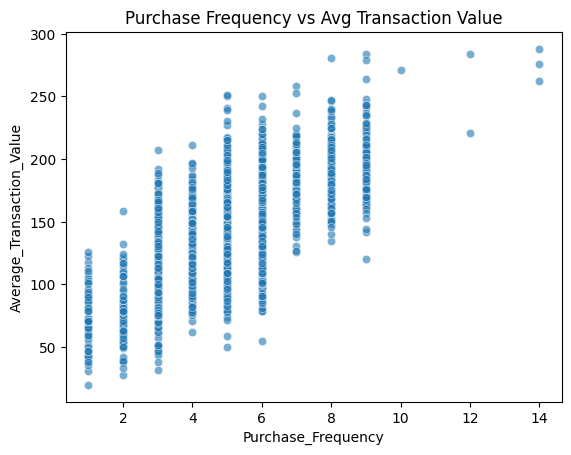

In [112]:
plt.figure()
sns.scatterplot(
    x="Purchase_Frequency",
    y="Average_Transaction_Value",
    data=df,
    alpha=0.6
)
plt.title("Purchase Frequency vs Avg Transaction Value")
plt.show()


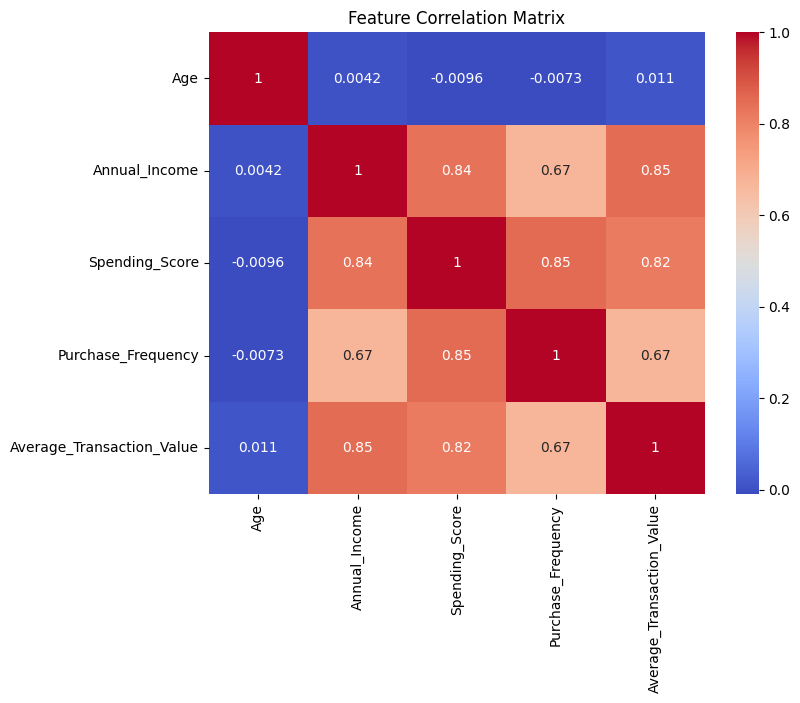

In [113]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[[
        "Age",
        "Annual_Income",
        "Spending_Score",
        "Purchase_Frequency",
        "Average_Transaction_Value"
    ]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Feature Correlation Matrix")
plt.show()


In [114]:
# Drop identifiers and non-ML columns
df_model = df.drop(columns=["CustomerID", "Name"])


In [115]:
df_model = pd.get_dummies(
    df_model,
    columns=["Gender", "Membership_Level"],
    drop_first=True
)


In [116]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_model)


In [117]:
scaled_df = pd.DataFrame(
    scaled_data,
    columns=df_model.columns
)

scaled_df.head()


,Age,Annual_Income,Spending_Score,Purchase_Frequency,Average_Transaction_Value,Gender_Male,Membership_Level_Gold,Membership_Level_Platinum,Membership_Level_Silver
0,0.763557,0.354259,-0.491737,-1.009256,0.678630,1.042920,-0.580429,-0.067233,0.724148
1,1.617537,1.823222,1.211115,1.119976,1.879636,-0.958846,1.722862,-0.067233,-1.380933
2,0.106649,-0.235709,-0.336933,-1.009256,-0.644928,-0.958846,-0.580429,-0.067233,0.724148
3,-0.813022,-0.361413,0.669299,0.587668,0.359995,-0.958846,-0.580429,-0.067233,0.724148
4,1.026320,-0.031973,-0.027323,-0.476948,-0.228252,-0.958846,-0.580429,-0.067233,0.724148


“Prior to clustering, irrelevant identifier columns were removed, categorical variables were encoded using one-hot encoding, and numerical features were standardized to ensure fair distance computation.

In [118]:
from sklearn.cluster import KMeans


In [119]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)


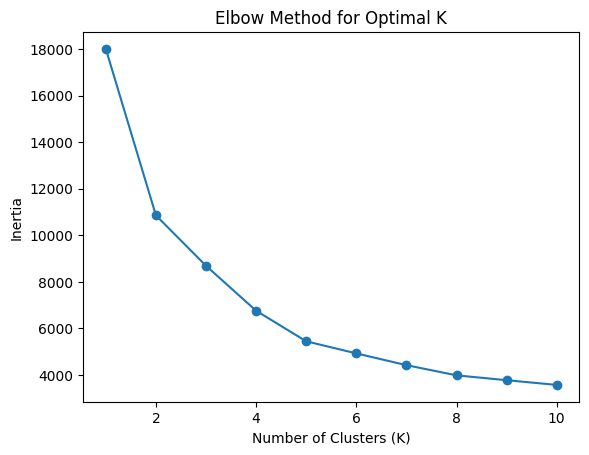

In [120]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()


In [121]:
#Train Final K-Means Model
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_df)


In [122]:
#Attach Cluster Labels Back to Data
df["Cluster"] = clusters
df.head()

,CustomerID,Name,Age,Gender,Annual_Income,Spending_Score,Purchase_Frequency,Average_Transaction_Value,Membership_Level,Cluster
0,CUST1000,Christopher Frey,56,Male,65509,36,3,169,Silver,3
1,CUST1001,Chad Ford,69,Female,87572,58,7,218,Gold,0
2,CUST1002,Dana Fitzgerald,46,Female,56648,38,3,115,Silver,3
3,CUST1003,Haley Johnson,32,Female,54760,51,6,156,Silver,3
4,CUST1004,Angela Mccarthy,60,Female,59708,42,4,132,Silver,3


In [123]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)
cluster_summary


,Age,Annual_Income,Spending_Score,Purchase_Frequency,Average_Transaction_Value
Cluster,,,,,
0,44.343254,78550.791667,57.581349,6.962302,185.283730
1,44.038462,33423.851648,20.736264,2.000000,76.862637
2,38.333333,106120.222222,81.888889,11.222222,266.777778
3,44.478161,56512.354789,39.213793,4.458238,132.453640


Cluster 0 → high income, high ATV, frequent buyers

Cluster 2 → low income, low spending, infrequent buyers

In [124]:
from sklearn.metrics import silhouette_score
 # measures how well each point fits within its cluster compared to other clusters.
sil_score = silhouette_score(scaled_df, clusters)
sil_score


np.float64(0.41302182930225545)

In [125]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = clusters
#PCA is for visualization, not for training K-Means.

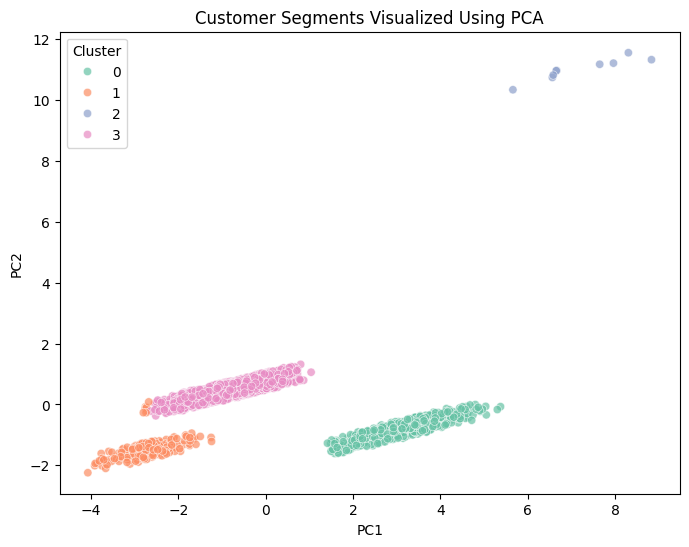

In [126]:



plt.figure(figsize=(8,6))
sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    data=pca_df,
    alpha=0.7
)
plt.title("Customer Segments Visualized Using PCA")
plt.show()


In [127]:
cluster_profile = df.groupby("Cluster").agg({
    "Age": "mean",
    "Annual_Income": "mean",
    "Spending_Score": "mean",
    "Purchase_Frequency": "mean",
    "Average_Transaction_Value": "mean"
})

cluster_profile


,Age,Annual_Income,Spending_Score,Purchase_Frequency,Average_Transaction_Value
Cluster,,,,,
0,44.343254,78550.791667,57.581349,6.962302,185.283730
1,44.038462,33423.851648,20.736264,2.000000,76.862637
2,38.333333,106120.222222,81.888889,11.222222,266.777778
3,44.478161,56512.354789,39.213793,4.458238,132.453640


In [128]:
cluster_names = {
    0: "Premium Loyal Customers",
    1: "Frequent Budget Shoppers",
    2: "Occasional High-Spenders",
    3: "Low-Engagement Customers"
}

df["Cluster_Name"] = df["Cluster"].map(cluster_names)
df.head()


,CustomerID,Name,Age,Gender,Annual_Income,Spending_Score,Purchase_Frequency,Average_Transaction_Value,Membership_Level,Cluster,Cluster_Name
0,CUST1000,Christopher Frey,56,Male,65509,36,3,169,Silver,3,Low-Engagement Customers
1,CUST1001,Chad Ford,69,Female,87572,58,7,218,Gold,0,Premium Loyal Customers
2,CUST1002,Dana Fitzgerald,46,Female,56648,38,3,115,Silver,3,Low-Engagement Customers
3,CUST1003,Haley Johnson,32,Female,54760,51,6,156,Silver,3,Low-Engagement Customers
4,CUST1004,Angela Mccarthy,60,Female,59708,42,4,132,Silver,3,Low-Engagement Customers


Hierarchical clustering builds clusters step-by-step by either merging or splitting data points based on distance.
Agglomerative (bottom-up) approach
Most common in real-world analysis

In [129]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt


In [130]:
linked = linkage(
    scaled_df,
    method="ward"   # minimizes variance within clusters
)
#Ward work well with Euclidean distance = Produces compact, meaningful clusters

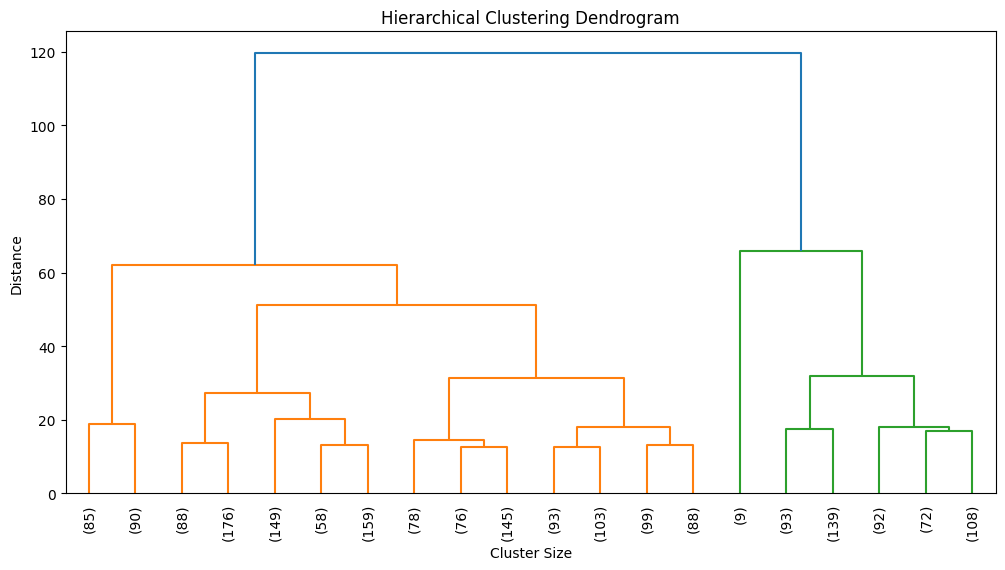

In [131]:
plt.figure(figsize=(12,6))
dendrogram(
    linked,
    truncate_mode="lastp",
    p=20,
    leaf_rotation=90,
    leaf_font_size=10
)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster Size")
plt.ylabel("Distance")
plt.show()


In [132]:
hierarchical = AgglomerativeClustering(
    n_clusters=4,
    metric="euclidean",
    linkage="ward"
)

hier_clusters = hierarchical.fit_predict(scaled_df)


In [133]:
df["Hierarchical_Cluster"] = hier_clusters
df.head()


,CustomerID,Name,Age,Gender,Annual_Income,Spending_Score,Purchase_Frequency,Average_Transaction_Value,Membership_Level,Cluster,Cluster_Name,Hierarchical_Cluster
0,CUST1000,Christopher Frey,56,Male,65509,36,3,169,Silver,3,Low-Engagement Customers,0
1,CUST1001,Chad Ford,69,Female,87572,58,7,218,Gold,0,Premium Loyal Customers,1
2,CUST1002,Dana Fitzgerald,46,Female,56648,38,3,115,Silver,3,Low-Engagement Customers,0
3,CUST1003,Haley Johnson,32,Female,54760,51,6,156,Silver,3,Low-Engagement Customers,0
4,CUST1004,Angela Mccarthy,60,Female,59708,42,4,132,Silver,3,Low-Engagement Customers,0


In [134]:
pd.crosstab(df["Cluster"], df["Hierarchical_Cluster"])
#Compare Cluster Distributions

Hierarchical_Cluster,0,1,2,3
Cluster,,,,
0,0,504,0,0
1,7,0,0,175
2,0,0,9,0
3,1305,0,0,0


In [135]:
import joblib

joblib.dump(scaler, "scaler.pkl")
joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(df_model.columns.tolist(), "feature_columns.pkl")


['feature_columns.pkl']